# IoT Device Classification and Location Prediction

## Project Overview

**Objective:** Train and evaluate a standalone RF device identification notebook that classifies IoT recordings by device type and location scenario.

**Problem statement:** Raw RF captures are difficult to compare directly. This workflow converts one-dimensional RF signals into spectrogram images and trains a convolutional neural network to recognize device-specific signal patterns.

**Dataset description:** The dataset consists of `.npy` RF recording files for six device/protocol classes: `dooralarm`, `lora`, `microphone`, `mbus`, `sigfox`, and `miwi`. Each recording is assigned to a scenario: `anotherroom`, `sameroom`, or `upstairs`.

**Input format:** A CSV manifest named `recordings_manifest.csv` points to the `.npy` recordings and provides `class`, `scenario`, `capture_id`, and `split` metadata. Each `.npy` file is expected to contain a one-dimensional signal array.

**Expected output:** The notebook trains a dual-output model, saves model files, writes evaluation artifacts, and produces file-level inference results. Predictions include device class, location class, confidence scores, confusion matrices, classification reports, and metadata.

**Model architecture summary:** The model uses RF spectrogram inputs, a four-block CNN feature extractor, configurable global pooling, a device softmax head, and a location softmax head. A stop-gradient layer prevents the location objective from updating the shared feature backbone.

**Evaluation metrics:** The notebook reports accuracy, classification reports, confusion matrices, per-class precision, recall, and F1 score at window level, plus whole-recording file-level accuracy with Wilson confidence intervals.

**Hardware requirements:** Training can be memory intensive because windows are converted to spectrogram tensors. A GPU is recommended. For a 48 GB system, `MAX_WINDOWS_PER_CLASS = 10000` is a reasonable starting point; reduce it on smaller systems.

## Environment Setup

Use Python 3.10 or newer. TensorFlow support varies by platform and Python release, so Python 3.10 is the recommended baseline for reproducible execution.

Required packages:

- `tensorflow`
- `numpy`
- `pandas`
- `scipy`
- `matplotlib`
- `seaborn`
- `scikit-learn`

Install dependencies with:

```bash
python -m pip install tensorflow "numpy<2" pandas scipy matplotlib seaborn scikit-learn
```

If your environment already pins TensorFlow-compatible versions, use those pins instead of upgrading everything at once.

## Dataset Structure

Expected folder layout:

```text
data/
├── recordings_manifest.csv
└── recordings/
    ├── dooralarm/
    ├── lora/
    ├── microphone/
    ├── mbus/
    ├── sigfox/
    └── miwi/
```

`recordings_manifest.csv` must contain one row per independent recording with these columns:

| Column | Meaning |
| --- | --- |
| `path` | Path to the `.npy` recording. Relative paths may be relative to the current folder, `DATASET_ROOT`, or the manifest folder. |
| `class` | Device label. Must match one of the entries in `CLASSES`. |
| `scenario` | Location/scenario label. Expected values are listed in `LOCATIONS`. |
| `capture_id` | Identifier for the independent capture. |
| `split` | One of `train`, `validation`, or `test`. |

To add a new recording, place the `.npy` file under the appropriate device folder and add a new manifest row. To add a new device, add a folder, add manifest rows, and update `CLASSES`, `NUM_CLASSES`, and any related reporting labels in the configuration cell.

## Execution Flow

Run the notebook from top to bottom:

1. **Imports and runtime information** load packages and print version/hardware details.
2. **Configuration** centralizes paths, labels, hyperparameters, and spectrogram settings.
3. **Reproducibility controls** set Python, NumPy, and TensorFlow seeds.
4. **Dataset validation and manifest processing** fail early if required files or columns are missing.
5. **Dataset statistics** summarize class and split balance before training.
6. **Signal preprocessing and spectrogram generation** define the feature extraction path.
7. **Dataset preparation** builds training, validation, and test tensors.
8. **Model definition and training** compile and train the dual-output CNN.
9. **Evaluation and visualization** save reports, plots, metadata, and file-level results.
10. **Single-recording inference** demonstrates prediction on one held-out file.

## Section 1: Imports and Runtime Information

In [1]:
from __future__ import annotations

import csv
import json
import math
import platform
import random
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy import signal as sg
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Concatenate,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GaussianNoise,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
)

print(f"Python version: {sys.version.split()[0]}")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor() or 'unknown'}")
print(f"GPU Available: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

Python version: 3.10.14
TensorFlow version: 2.21.0
NumPy version: 1.26.4
Pandas version: 2.3.3
Platform: macOS-26.5.1-arm64-arm-64bit
Processor: arm
GPU Available: False
GPUs: []


## Section 2: Configuration

This cell is the single place to change paths, labels, hyperparameters, spectrogram settings, and artifact locations. Keep changes here so runs are easy to reproduce and review.

In [2]:
# Paths
DATASET_ROOT = Path("./data")
MANIFEST_PATH = DATASET_ROOT / "recordings_manifest.csv"
MODEL_DIR = Path("./models/notebook_manifest_avgmax_10000")
RESULTS_DIR = Path("./results/notebook_manifest_avgmax_10000")

# Labels
LOCATIONS = ["anotherroom", "sameroom", "upstairs"]
CLASSES = ["dooralarm", "lora", "microphone", "mbus", "sigfox", "miwi"]
NUM_CLASSES = len(CLASSES)
NUM_LOCATIONS = len(LOCATIONS)

# Signal and spectrogram settings
SAMPLE_RATE = None  # Set this if recordings have a known sampling rate needed for interpretation.
WINDOW_SIZE = 4096
FFT_SIZE = 512
SPECTROGRAM_CONFIG = {
    "window": "hann",
    "nperseg": 256,
    "noverlap": 192,
    "nfft": FFT_SIZE,
    "scaling": "spectrum",
}

# Training settings
BATCH_SIZE = 32
EPOCHS = 50
RANDOM_SEED = 42
POOLING = "avgmax"
MAX_WINDOWS_PER_CLASS = 10000
LEARNING_RATE = 3e-4

# Inference settings
AGGREGATION = "mean"
TOP_FRACTION = 0.25
INFERENCE_STEP = 1024

# Legacy one-file-per-class names, used only if you choose directory-based loading.
DATA_FILES = {class_name: f"{class_name}.npy" for class_name in CLASSES}
TEST_DATA_FILES = {class_name: f"{class_name}_test.npy" for class_name in CLASSES}

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

config_summary = pd.DataFrame(
    [
        ("DATASET_ROOT", str(DATASET_ROOT)),
        ("MANIFEST_PATH", str(MANIFEST_PATH)),
        ("MODEL_DIR", str(MODEL_DIR)),
        ("RESULTS_DIR", str(RESULTS_DIR)),
        ("SAMPLE_RATE", SAMPLE_RATE),
        ("WINDOW_SIZE", WINDOW_SIZE),
        ("FFT_SIZE", FFT_SIZE),
        ("BATCH_SIZE", BATCH_SIZE),
        ("EPOCHS", EPOCHS),
        ("RANDOM_SEED", RANDOM_SEED),
        ("POOLING", POOLING),
        ("MAX_WINDOWS_PER_CLASS", MAX_WINDOWS_PER_CLASS),
        ("LEARNING_RATE", LEARNING_RATE),
        ("AGGREGATION", AGGREGATION),
        ("TOP_FRACTION", TOP_FRACTION),
        ("INFERENCE_STEP", INFERENCE_STEP),
    ],
    columns=["Parameter", "Value"],
)
config_summary

,Parameter,Value
0,DATASET_ROOT,data
1,MANIFEST_PATH,data/recordings_manifest.csv
2,MODEL_DIR,models/notebook_manifest_avgmax_10000
3,RESULTS_DIR,results/notebook_manifest_avgmax_10000
4,SAMPLE_RATE,None
5,WINDOW_SIZE,4096
6,FFT_SIZE,512
7,BATCH_SIZE,32
8,EPOCHS,50
9,RANDOM_SEED,42


## Section 3: Reproducibility Controls

Setting seeds makes repeated runs easier to compare. Some TensorFlow GPU operations can still be nondeterministic depending on hardware and installed kernels, but these controls remove avoidable randomness from Python, NumPy, and TensorFlow.

In [3]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Reproducibility seeds set to {RANDOM_SEED}")

Reproducibility seeds set to 42


## Section 4: Dataset Loading and Validation

These helpers load manifest rows, resolve recording paths, validate required inputs, and provide actionable errors for common setup issues before training starts.

In [4]:
@dataclass(frozen=True)
class Recording:
    """One independently captured signal file and its experimental metadata."""

    path: Path
    class_name: str
    scenario: str = "unspecified"
    capture_id: str = ""
    split: str | None = None


def resolve_manifest_signal_path(raw_path: str, manifest_path: Path, dataset_root: Path) -> Path:
    """Resolve manifest paths without depending on any fixed folder layout."""
    path = Path(raw_path.strip()).expanduser()
    candidates = []

    if path.is_absolute():
        candidates.append(path)
    else:
        candidates.extend([
            path,
            dataset_root / path,
            manifest_path.parent / path,
            manifest_path.parent / path.name,
        ])
        if path.parts and path.parts[0] == dataset_root.name:
            candidates.append(dataset_root / Path(*path.parts[1:]))

    for candidate in candidates:
        if candidate.exists():
            return candidate

    checked = ", ".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"Referenced recording file does not exist: {raw_path}. Checked: {checked}")


def load_signal_file(path: Path) -> np.ndarray:
    """Load a recording with an informative error if the file is unreadable."""
    try:
        data = np.load(path)
    except Exception as exc:
        raise ValueError(f"Could not load recording file {path}. Confirm it is a valid .npy array. Original error: {exc}") from exc

    data = np.asarray(data)
    if data.size == 0:
        raise ValueError(f"Recording file is empty: {path}")
    return data


def validate_dataset_inputs(
    dataset_root: Path,
    manifest_path: Path,
    classes: list[str],
    locations: list[str],
) -> None:
    """Fail early when dataset inputs are missing or malformed."""
    dataset_root = Path(dataset_root).expanduser()
    manifest_path = Path(manifest_path).expanduser()
    required_columns = {"path", "class", "scenario", "capture_id", "split"}

    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset root not found: {dataset_root}. Update DATASET_ROOT in the configuration cell.")
    if not dataset_root.is_dir():
        raise NotADirectoryError(f"Dataset root is not a directory: {dataset_root}")
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest file not found: {manifest_path}. Update MANIFEST_PATH in the configuration cell.")
    if manifest_path.stat().st_size == 0:
        raise ValueError(f"Manifest file is empty: {manifest_path}")
    if len(classes) < 2:
        raise ValueError("At least two classes are required for classification.")

    with manifest_path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        fieldnames = reader.fieldnames or []
        missing_columns = required_columns.difference(fieldnames)
        if missing_columns:
            missing_text = ", ".join(sorted(missing_columns))
            raise ValueError(f"Manifest is missing required column(s): {missing_text}")

        rows = list(reader)

    if not rows:
        raise ValueError(f"Manifest contains no recording rows: {manifest_path}")

    seen_classes: set[str] = set()
    for row_number, row in enumerate(rows, start=2):
        class_name = row["class"].strip()
        scenario = row["scenario"].strip()
        split = row["split"].strip()
        if class_name not in classes:
            raise ValueError(f"Manifest row {row_number} has unknown class: {class_name}")
        if scenario and scenario not in locations:
            raise ValueError(f"Manifest row {row_number} has unknown scenario: {scenario}")
        if split not in {"train", "validation", "test"}:
            raise ValueError(f"Manifest row {row_number} has invalid split: {split}")
        resolve_manifest_signal_path(row["path"], manifest_path, dataset_root)
        seen_classes.add(class_name)

    if len(seen_classes) < 2:
        raise ValueError("Manifest must contain at least two classes.")


def load_manifest(
    manifest_path: Path,
    classes: list[str] | None = None,
    split: str | None = None,
    dataset_root: Path = DATASET_ROOT,
) -> list[Recording]:
    """Load recording assignments from a CSV manifest."""
    classes = classes or CLASSES
    manifest_path = Path(manifest_path).expanduser()
    dataset_root = Path(dataset_root).expanduser()
    required_columns = {"path", "class", "scenario", "capture_id", "split"}
    all_recordings: list[Recording] = []

    with manifest_path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        missing = required_columns.difference(reader.fieldnames or [])
        if missing:
            missing_text = ", ".join(sorted(missing))
            raise ValueError(f"Manifest {manifest_path} is missing columns: {missing_text}")

        for row_number, row in enumerate(reader, start=2):
            class_name = row["class"].strip()
            if class_name not in classes:
                raise ValueError(f"Manifest {manifest_path} row {row_number} has unknown class: {class_name}")

            path = resolve_manifest_signal_path(row["path"], manifest_path, dataset_root)
            all_recordings.append(
                Recording(
                    path=path,
                    class_name=class_name,
                    scenario=row["scenario"].strip() or "unspecified",
                    capture_id=row["capture_id"].strip(),
                    split=row["split"].strip() or None,
                )
            )

    assigned_paths: dict[Path, str | None] = {}
    for recording in all_recordings:
        normalized_path = recording.path.resolve()
        if normalized_path in assigned_paths:
            raise ValueError(f"Manifest {manifest_path} assigns recording more than once: {recording.path}")
        assigned_paths[normalized_path] = recording.split

    recordings = [recording for recording in all_recordings if split is None or recording.split == split]
    if not recordings:
        requested = f" for split={split}" if split else ""
        raise ValueError(f"Manifest {manifest_path} contains no recordings{requested}")

    return recordings


def class_file_candidates(
    class_name: str,
    file_map: dict[str, str] | None = None,
    file_template: str | None = None,
) -> list[str]:
    """Return supported file names for a class, in lookup order."""
    if file_map is not None:
        return [file_map[class_name]]
    if file_template is not None:
        return [file_template.format(class_name=class_name, class_label=class_name)]
    return [DATA_FILES.get(class_name, f"{class_name}.npy"), TEST_DATA_FILES.get(class_name, f"{class_name}_test.npy")]


def find_class_signal_path(
    data_dir: Path,
    class_name: str,
    file_map: dict[str, str] | None = None,
    file_template: str | None = None,
) -> Path:
    """Find a class signal file in a directory."""
    candidates = [data_dir / name for name in class_file_candidates(class_name, file_map, file_template)]
    for path in candidates:
        if path.exists():
            return path

    expected = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Missing required data file for {class_name}. Expected one of: {expected}")


def iter_class_signal_paths(
    data_dir: Path,
    classes: list[str] | None = None,
    file_map: dict[str, str] | None = None,
    file_template: str | None = None,
    allow_missing: bool = False,
) -> list[tuple[str, Path]]:
    """List labeled signal files available in a directory."""
    classes = classes or CLASSES
    paths: list[tuple[str, Path]] = []

    for class_name in classes:
        try:
            paths.append((class_name, find_class_signal_path(data_dir, class_name, file_map, file_template)))
        except FileNotFoundError:
            if allow_missing:
                continue
            raise

    if not paths:
        raise FileNotFoundError(f"No labeled .npy files found in {data_dir}")

    return paths


def legacy_recordings(
    data_dir: Path,
    classes: list[str] | None = None,
    file_map: dict[str, str] | None = None,
    file_template: str | None = None,
    allow_missing: bool = False,
) -> list[Recording]:
    """Represent one-file-per-class data directories as recording metadata."""
    return [
        Recording(path=path, class_name=class_name)
        for class_name, path in iter_class_signal_paths(
            data_dir,
            classes=classes,
            file_map=file_map,
            file_template=file_template,
            allow_missing=allow_missing,
        )
    ]

## Section 5: Manifest Processing

This section validates the dataset, loads the manifest, and confirms the recording-level split. Whole recordings are assigned to `train`, `validation`, and `test` before segmentation to avoid leakage between splits.

In [5]:
validate_dataset_inputs(DATASET_ROOT, MANIFEST_PATH, CLASSES, LOCATIONS)
recordings = load_manifest(MANIFEST_PATH, classes=CLASSES, dataset_root=DATASET_ROOT)

split_counts = Counter(r.split or "unspecified" for r in recordings)
scenario_counts = Counter(r.scenario for r in recordings)
class_counts = Counter(r.class_name for r in recordings)
class_by_split = defaultdict(Counter)
scenario_by_split = defaultdict(Counter)
paths = Counter(str(r.path.resolve()) for r in recordings)

missing_files = [str(r.path) for r in recordings if not r.path.exists()]
duplicate_paths = [path for path, count in paths.items() if count > 1]

for r in recordings:
    class_by_split[r.split][r.class_name] += 1
    scenario_by_split[r.split][r.scenario] += 1

print(f"Total recordings: {len(recordings)}")
print(f"Number of classes: {len(class_counts)}")
print(f"By split: {dict(sorted(split_counts.items()))}")
print(f"By scenario: {dict(sorted(scenario_counts.items()))}")
print(f"By class: {dict((c, class_counts[c]) for c in CLASSES)}")
print(f"Missing files: {len(missing_files)}")
print(f"Duplicate paths: {len(duplicate_paths)}")

for split in ("train", "validation", "test"):
    print(f"\n{split.upper()}")
    print("  classes:", dict((c, class_by_split[split][c]) for c in CLASSES))
    print("  scenarios:", dict((s, scenario_by_split[split][s]) for s in LOCATIONS))

Total recordings: 378
Number of classes: 6
By split: {'test': 18, 'train': 288, 'validation': 72}
By scenario: {'anotherroom': 126, 'sameroom': 126, 'upstairs': 126}
By class: {'dooralarm': 63, 'lora': 63, 'microphone': 63, 'mbus': 63, 'sigfox': 63, 'miwi': 63}
Missing files: 0
Duplicate paths: 0

TRAIN
  classes: {'dooralarm': 48, 'lora': 48, 'microphone': 48, 'mbus': 48, 'sigfox': 48, 'miwi': 48}
  scenarios: {'anotherroom': 96, 'sameroom': 96, 'upstairs': 96}

VALIDATION
  classes: {'dooralarm': 12, 'lora': 12, 'microphone': 12, 'mbus': 12, 'sigfox': 12, 'miwi': 12}
  scenarios: {'anotherroom': 24, 'sameroom': 24, 'upstairs': 24}

TEST
  classes: {'dooralarm': 3, 'lora': 3, 'microphone': 3, 'mbus': 3, 'sigfox': 3, 'miwi': 3}
  scenarios: {'anotherroom': 6, 'sameroom': 6, 'upstairs': 6}


## Section 6: Dataset Statistics

These summaries and charts help reviewers inspect class balance and split coverage before any expensive tensor construction or training begins.

     class  total  train  validation  test
 dooralarm     63     48          12     3
      lora     63     48          12     3
microphone     63     48          12     3
      mbus     63     48          12     3
    sigfox     63     48          12     3
      miwi     63     48          12     3


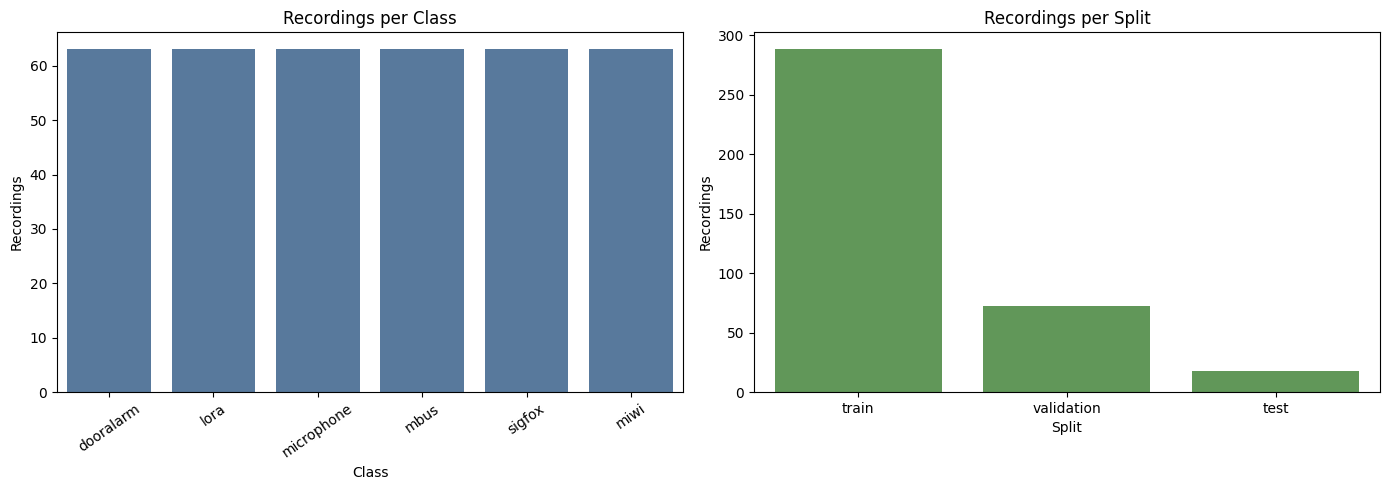

In [6]:
stats_rows = [
    {
        "class": class_name,
        "total": class_counts[class_name],
        "train": class_by_split["train"][class_name],
        "validation": class_by_split["validation"][class_name],
        "test": class_by_split["test"][class_name],
    }
    for class_name in CLASSES
]
stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=stats_df, x="class", y="total", ax=axes[0], color="#4c78a8")
axes[0].set_title("Recordings per Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Recordings")
axes[0].tick_params(axis="x", rotation=35)

split_df = pd.DataFrame(
    [{"split": split, "recordings": split_counts[split]} for split in ["train", "validation", "test"]]
)
sns.barplot(data=split_df, x="split", y="recordings", ax=axes[1], color="#59a14f")
axes[1].set_title("Recordings per Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Recordings")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dataset_statistics.png", dpi=160)
plt.show(block=False)

## Section 7: Signal Preprocessing

Raw signals are flattened, segmented into fixed-size windows, and normalized per window. This keeps each training example on a comparable scale while preserving signal shape for spectrogram conversion.

In [7]:
def segment_signal(data: np.ndarray, window_size: int = WINDOW_SIZE) -> np.ndarray:
    """Split a one-dimensional signal into non-overlapping fixed-size windows."""
    data = np.asarray(data).reshape(-1)
    num_samples = len(data) // window_size
    if num_samples == 0:
        return np.empty((0, window_size), dtype=data.dtype)
    return data[: num_samples * window_size].reshape(num_samples, window_size)


def sliding_windows(data: np.ndarray, window_size: int = WINDOW_SIZE, step: int = INFERENCE_STEP) -> np.ndarray:
    """Split a signal into overlapping windows for inference-time voting."""
    data = np.asarray(data).reshape(-1)
    if len(data) < window_size:
        return np.empty((0, window_size), dtype=data.dtype)
    windows = [data[start : start + window_size] for start in range(0, len(data) - window_size + 1, step)]
    return np.asarray(windows)


def normalize_windows(windows: np.ndarray) -> np.ndarray:
    """Normalize each RF window independently."""
    windows = np.asarray(windows)
    normalized = (windows - np.mean(windows, axis=1, keepdims=True)) / (np.std(windows, axis=1, keepdims=True) + 1e-8)
    if np.iscomplexobj(normalized):
        return normalized.astype(np.complex64)
    return normalized.astype(np.float32)


def class_distribution(labels) -> dict[int, int]:
    """Return a deterministic class-count dictionary."""
    unique, counts = np.unique(np.asarray(list(labels)), return_counts=True)
    return {int(label): int(count) for label, count in zip(unique, counts)}

## Section 8: Spectrogram Generation

Each normalized window is converted into a log-compressed spectrogram using the configured FFT settings. The resulting tensor shape is compatible with a 2D CNN.

In [8]:
def create_spectrograms(
    windows: np.ndarray,
    spectrogram_config: dict[str, object] | None = None,
) -> np.ndarray:
    """Create normalized log-compressed spectrograms with a channel dimension."""
    config = spectrogram_config or SPECTROGRAM_CONFIG
    specs = []

    for window in windows:
        _, _, spectrum = sg.spectrogram(window, **config)
        spec = np.log1p(spectrum)
        spec = (spec - np.mean(spec)) / (np.std(spec) + 1e-8)
        specs.append(spec.astype(np.float32))

    if not specs:
        return np.empty((0, 0, 0, 1), dtype=np.float32)

    return np.asarray(specs, dtype=np.float32)[..., np.newaxis]


def windows_to_model_input(windows: np.ndarray) -> np.ndarray:
    """Apply the full preprocessing path used by both training and inference."""
    if len(windows) == 0:
        return np.empty((0, 0, 0, 1), dtype=np.float32)

    normalized = normalize_windows(windows)
    return create_spectrograms(normalized)

## Section 9: Dataset Preparation

Training, validation, and held-out test windows are built from the manifest. The preparation logic loads recordings, segments them, reservoir-samples up to `MAX_WINDOWS_PER_CLASS` windows per class, balances classes, and converts windows to model-ready spectrogram tensors.

In [9]:
def build_dataset(
    data_dir: Path | None = None,
    classes: list[str] | None = None,
    locations: list[str] | None = None,
    window_size: int = WINDOW_SIZE,
    balance: bool = True,
    seed: int = RANDOM_SEED,
    file_map: dict[str, str] | None = None,
    file_template: str | None = None,
    allow_missing: bool = False,
    manifest_path: Path | None = None,
    split: str | None = None,
    max_windows_per_class: int | None = None,
    dataset_root: Path = DATASET_ROOT,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build model inputs from one-file-per-class directories or a multi-recording manifest."""
    classes = classes or CLASSES
    locations = locations or LOCATIONS
    if manifest_path is not None:
        recordings_for_build = load_manifest(manifest_path, classes=classes, split=split, dataset_root=dataset_root)
    elif data_dir is not None:
        recordings_for_build = legacy_recordings(
            data_dir,
            classes=classes,
            file_map=file_map,
            file_template=file_template,
            allow_missing=allow_missing,
        )
    else:
        raise ValueError("Provide data_dir or manifest_path")

    return build_dataset_from_recordings(
        recordings_for_build,
        classes=classes,
        locations=locations,
        window_size=window_size,
        balance=balance,
        seed=seed,
        allow_missing=allow_missing,
        max_windows_per_class=max_windows_per_class,
    )


def build_dataset_from_recordings(
    recordings_for_build: list[Recording],
    classes: list[str] | None = None,
    locations: list[str] | None = None,
    window_size: int = WINDOW_SIZE,
    balance: bool = True,
    seed: int = RANDOM_SEED,
    allow_missing: bool = False,
    max_windows_per_class: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Create window inputs after recordings have already been assigned a split."""
    classes = classes or CLASSES
    locations = locations or LOCATIONS
    if max_windows_per_class is not None and max_windows_per_class <= 0:
        raise ValueError("max_windows_per_class must be positive")

    entries_by_class: dict[str, list[tuple[np.ndarray, int, int]]] = {class_name: [] for class_name in classes}
    windows_seen: dict[str, int] = {class_name: 0 for class_name in classes}
    rng = np.random.default_rng(seed)

    for recording in recordings_for_build:
        if recording.class_name not in classes:
            raise ValueError(f"Unknown recording class: {recording.class_name}")

        device_idx = classes.index(recording.class_name)
        location_idx = locations.index(recording.scenario) if recording.scenario in locations else -1

        raw = load_signal_file(recording.path)
        windows = segment_signal(raw, window_size=window_size)
        if len(windows) == 0:
            raise ValueError(f"{recording.path} has fewer than {window_size} samples and cannot be segmented")

        if max_windows_per_class is None:
            for window in windows:
                entries_by_class[recording.class_name].append((window, device_idx, location_idx))
            continue

        samples = entries_by_class[recording.class_name]
        for window in windows:
            windows_seen[recording.class_name] += 1
            seen = windows_seen[recording.class_name]
            entry = (np.array(window, copy=True), device_idx, location_idx)
            if len(samples) < max_windows_per_class:
                samples.append(entry)
                continue
            candidate = int(rng.integers(0, seen))
            if candidate < max_windows_per_class:
                samples[candidate] = entry

    missing = [name for name, entries in entries_by_class.items() if not entries]
    if missing and not allow_missing:
        raise ValueError(f"No recordings provided for classes: {', '.join(missing)}")

    class_entries = {class_name: entries for class_name, entries in entries_by_class.items() if entries}
    balanced_limit = min(len(entries) for entries in class_entries.values()) if balance else None

    all_specs: list[np.ndarray] = []
    all_device_labels: list[np.ndarray] = []
    all_location_labels: list[np.ndarray] = []

    for class_name in classes:
        if class_name not in class_entries:
            continue
        entries = class_entries[class_name]
        limit = balanced_limit if balance else len(entries)
        if max_windows_per_class is not None:
            limit = min(limit, max_windows_per_class)
        if len(entries) > limit:
            indices = np.sort(rng.choice(len(entries), size=limit, replace=False))
            entries = [entries[i] for i in indices]

        windows_array = np.asarray([entry[0] for entry in entries])
        all_specs.append(windows_to_model_input(windows_array))
        all_device_labels.append(np.array([entry[1] for entry in entries], dtype=np.int64))
        all_location_labels.append(np.array([entry[2] for entry in entries], dtype=np.int64))

    x = np.concatenate(all_specs, axis=0)
    y_device = np.concatenate(all_device_labels, axis=0)
    y_location = np.concatenate(all_location_labels, axis=0)

    return shuffle(x, y_device, y_location, random_state=seed)

In [10]:
print("Building training set...")
X_train, y_dev_train, y_loc_train = build_dataset(
    manifest_path=MANIFEST_PATH,
    split="train",
    classes=CLASSES,
    locations=LOCATIONS,
    balance=True,
    seed=RANDOM_SEED,
    max_windows_per_class=MAX_WINDOWS_PER_CLASS,
    dataset_root=DATASET_ROOT,
)

print("Building validation set...")
X_val, y_dev_val, y_loc_val = build_dataset(
    manifest_path=MANIFEST_PATH,
    split="validation",
    classes=CLASSES,
    locations=LOCATIONS,
    balance=True,
    seed=RANDOM_SEED,
    max_windows_per_class=MAX_WINDOWS_PER_CLASS,
    dataset_root=DATASET_ROOT,
)

print("Building test set...")
X_test, y_dev_test, y_loc_test = build_dataset(
    manifest_path=MANIFEST_PATH,
    split="test",
    classes=CLASSES,
    locations=LOCATIONS,
    balance=True,
    seed=RANDOM_SEED,
    allow_missing=True,
    max_windows_per_class=MAX_WINDOWS_PER_CLASS,
    dataset_root=DATASET_ROOT,
)

dataset_tensor_summary = pd.DataFrame(
    [
        ("train", X_train.shape, class_distribution(y_dev_train), class_distribution(y_loc_train)),
        ("validation", X_val.shape, class_distribution(y_dev_val), class_distribution(y_loc_val)),
        ("test", X_test.shape, class_distribution(y_dev_test), class_distribution(y_loc_test)),
    ],
    columns=["split", "X shape", "device distribution", "location distribution"],
)
print(dataset_tensor_summary.to_string(index=False))

Building training set...
Building validation set...
Building test set...
     split             X shape                                          device distribution          location distribution
     train (60000, 257, 61, 1) {0: 10000, 1: 10000, 2: 10000, 3: 10000, 4: 10000, 5: 10000} {0: 19942, 1: 20035, 2: 20023}
validation (60000, 257, 61, 1) {0: 10000, 1: 10000, 2: 10000, 3: 10000, 4: 10000, 5: 10000} {0: 20042, 1: 19972, 2: 19986}
      test (43938, 257, 61, 1)       {0: 7323, 1: 7323, 2: 7323, 3: 7323, 4: 7323, 5: 7323} {0: 14646, 1: 14646, 2: 14646}


## Section 10: Model Definition

This section defines and compiles the dual-output CNN. The architecture is intentionally unchanged from the established workflow.

In [11]:
@tf.keras.utils.register_keras_serializable(package="iot")
class StopGradientLayer(tf.keras.layers.Layer):
    """Pass-through layer that blocks gradient flow."""

    def call(self, inputs):
        return tf.stop_gradient(inputs)


def build_cnn(
    input_shape: tuple[int, int, int],
    num_classes: int,
    num_locations: int = 3,
    learning_rate: float = 3e-4,
    pooling: str = "avg",
) -> tf.keras.Model:
    """Build and compile the spectrogram CNN with configurable pooling."""
    if pooling not in {"avg", "max", "avgmax", "flatten"}:
        raise ValueError(f"Unknown pooling type: {pooling}")

    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.003)(inputs)
    x = Conv2D(32, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(256, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    if pooling == "flatten":
        features = Flatten()(x)
    elif pooling == "avg":
        features = GlobalAveragePooling2D()(x)
    elif pooling == "max":
        features = GlobalMaxPooling2D()(x)
    else:
        features = Concatenate()([GlobalAveragePooling2D()(x), GlobalMaxPooling2D()(x)])

    shared = Dense(256, activation="relu")(features)
    shared = Dropout(0.25)(shared)
    device_output = Dense(num_classes, activation="softmax", name="device")(shared)

    location_features = StopGradientLayer()(features)
    loc_branch = Dense(128, activation="relu")(location_features)
    loc_branch = Dropout(0.3)(loc_branch)
    loc_branch = Dense(64, activation="relu")(loc_branch)
    location_output = Dense(num_locations, activation="softmax", name="location")(loc_branch)

    compiled_model = tf.keras.Model(inputs=inputs, outputs=[device_output, location_output])
    compiled_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss={"device": "categorical_crossentropy", "location": "categorical_crossentropy"},
        loss_weights={"device": 1.0, "location": 0.5},
        metrics={"device": ["accuracy"], "location": ["accuracy"]},
    )
    return compiled_model

## Section 11: Model Summary

The model summary confirms tensor shapes and layer counts before training. The parameter table gives reviewers a compact overview of model size.

In [12]:
model = build_cnn(
    input_shape=X_train.shape[1:],
    num_classes=NUM_CLASSES,
    num_locations=NUM_LOCATIONS,
    learning_rate=LEARNING_RATE,
    pooling=POOLING,
)
model.summary()

model_parameter_summary = pd.DataFrame(
    [
        ("Total parameters", int(model.count_params())),
        ("Trainable parameters", int(sum(np.prod(v.shape) for v in model.trainable_weights))),
        ("Non-trainable parameters", int(sum(np.prod(v.shape) for v in model.non_trainable_weights))),
    ],
    columns=["Metric", "Value"],
)
model_parameter_summary

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 257, 61,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 257, 61,   │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 257, 61,   │        320 │ gaussian_noise[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 257, 61,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 257, 61,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 30,   │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 30,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 30,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 30,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 15,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 15,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 15,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 15,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 7,     │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 7,     │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 7,     │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 7,     │          0 │ batch_normalizat

 Total params: 596,745 (2.28 MB)

 Trainable params: 595,785 (2.27 MB)

 Non-trainable params: 960 (3.75 KB)

,Metric,Value
0,Total parameters,596745
1,Trainable parameters,595785
2,Non-trainable parameters,960


## Section 12: Training

Training uses early stopping, learning-rate reduction, and best-model checkpointing based on device validation accuracy. The callbacks and training workflow are unchanged.

In [13]:
y_dev_train_cat = tf.keras.utils.to_categorical(y_dev_train, NUM_CLASSES)
y_dev_val_cat = tf.keras.utils.to_categorical(y_dev_val, NUM_CLASSES)
y_dev_test_cat = tf.keras.utils.to_categorical(y_dev_test, NUM_CLASSES)

y_loc_train_cat = tf.keras.utils.to_categorical(y_loc_train, NUM_LOCATIONS)
y_loc_val_cat = tf.keras.utils.to_categorical(y_loc_val, NUM_LOCATIONS)
y_loc_test_cat = tf.keras.utils.to_categorical(y_loc_test, NUM_LOCATIONS)

best_model_path = MODEL_DIR / "best_iot_classifier.h5"
final_model_path = MODEL_DIR / "final_iot_classifier.h5"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_device_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode="min",
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_device_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        str(best_model_path),
        monitor="val_device_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    {"device": y_dev_train_cat, "location": y_loc_train_cat},
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, {"device": y_dev_val_cat, "location": y_loc_val_cat}),
    callbacks=callbacks,
    verbose=1,
)

model.save(str(final_model_path))
print(f"Saved best model: {best_model_path}")
print(f"Saved final model: {final_model_path}")

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - device_accuracy: 0.5926 - device_loss: 1.0076 - location_accuracy: 0.4433 - location_loss: 1.0512 - loss: 1.5331
Epoch 1: val_device_accuracy improved from None to 0.70167, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 449s 238ms/step - device_accuracy: 0.6617 - device_loss: 0.8170 - location_accuracy: 0.5099 - location_loss: 0.9430 - loss: 1.2885 - val_device_accuracy: 0.7017 - val_device_loss: 0.6886 - val_location_accuracy: 0.5185 - val_location_loss: 0.9011 - val_loss: 1.1391 - learning_rate: 3.0000e-04
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - device_accuracy: 0.7449 - device_loss: 0.6200 - location_accuracy: 0.6048 - location_loss: 0.8016 - loss: 1.0208
Epoch 2: val_device_accuracy improved from 0.70167 to 0.72335, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 454s 242ms/step - device_accuracy: 0.7548 - device_loss: 0.5931 - location_accuracy: 0.6177 - location_loss: 0.7800 - loss: 0.9831 - val_device_accuracy: 0.7233 - val_device_loss: 0.6321 - val_location_accuracy: 0.5957 - val_location_loss: 0.7776 - val_loss: 1.0209 - learning_rate: 3.0000e-04
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - device_accuracy: 0.7824 - device_loss: 0.5324 - location_accuracy: 0.6410 - location_loss: 0.7326 - loss: 0.8987
Epoch 3: val_device_accuracy did not improve from 0.72335
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 438s 234ms/step - device_accuracy: 0.7880 - device_loss: 0.5151 - location_accuracy: 0.6427 - location_loss: 0.7280 - loss: 0.8791 - val_device_accuracy: 0.7176 - val_device_loss: 0.7071 - val_location_accuracy: 0.5997 - val_location_loss: 0.7827 - val_loss: 1.0985 - learning_rate: 3.0000e-04
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - device_accuracy: 0.8070 - device_loss: 0.4731 - location_accura

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 422s 225ms/step - device_accuracy: 0.8124 - device_loss: 0.4587 - location_accuracy: 0.6622 - location_loss: 0.6987 - loss: 0.8081 - val_device_accuracy: 0.7387 - val_device_loss: 0.6191 - val_location_accuracy: 0.6235 - val_location_loss: 0.7291 - val_loss: 0.9837 - learning_rate: 3.0000e-04
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - device_accuracy: 0.8339 - device_loss: 0.4173 - location_accuracy: 0.6733 - location_loss: 0.6763 - loss: 0.7555
Epoch 5: val_device_accuracy improved from 0.73865 to 0.74292, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 444s 237ms/step - device_accuracy: 0.8399 - device_loss: 0.4035 - location_accuracy: 0.6761 - location_loss: 0.6749 - loss: 0.7410 - val_device_accuracy: 0.7429 - val_device_loss: 0.6338 - val_location_accuracy: 0.6428 - val_location_loss: 0.7132 - val_loss: 0.9904 - learning_rate: 3.0000e-04
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - device_accuracy: 0.8518 - device_loss: 0.3671 - location_accuracy: 0.6870 - location_loss: 0.6551 - loss: 0.6947
Epoch 6: val_device_accuracy improved from 0.74292 to 0.74670, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 307s 164ms/step - device_accuracy: 0.9971 - device_loss: 0.0133 - location_accuracy: 0.7585 - location_loss: 0.5168 - loss: 0.2717 - val_device_accuracy: 0.7889 - val_device_loss: 1.0405 - val_location_accuracy: 0.7170 - val_location_loss: 0.6055 - val_loss: 1.3433 - learning_rate: 4.6875e-06
Epoch 24/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - device_accuracy: 0.9966 - device_loss: 0.0149 - location_accuracy: 0.7602 - location_loss: 0.5149 - loss: 0.2724
Epoch 24: val_device_accuracy improved from 0.78887 to 0.78893, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 318s 170ms/step - device_accuracy: 0.9973 - device_loss: 0.0129 - location_accuracy: 0.7581 - location_loss: 0.5166 - loss: 0.2712 - val_device_accuracy: 0.7889 - val_device_loss: 1.0460 - val_location_accuracy: 0.7164 - val_location_loss: 0.6056 - val_loss: 1.3488 - learning_rate: 4.6875e-06
Epoch 25/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - device_accuracy: 0.9968 - device_loss: 0.0145 - location_accuracy: 0.7566 - location_loss: 0.5177 - loss: 0.2733
Epoch 25: ReduceLROnPlateau reducing learning rate to 2.3437501113221515e-06.

Epoch 25: val_device_accuracy improved from 0.78893 to 0.78905, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 332s 177ms/step - device_accuracy: 0.9973 - device_loss: 0.0128 - location_accuracy: 0.7571 - location_loss: 0.5182 - loss: 0.2719 - val_device_accuracy: 0.7890 - val_device_loss: 1.0510 - val_location_accuracy: 0.7173 - val_location_loss: 0.6055 - val_loss: 1.3537 - learning_rate: 4.6875e-06
Epoch 26/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - device_accuracy: 0.9970 - device_loss: 0.0136 - location_accuracy: 0.7586 - location_loss: 0.5141 - loss: 0.2707
Epoch 26: val_device_accuracy improved from 0.78905 to 0.78942, saving model to models/notebook_manifest_avgmax_10000/best_iot_classifier.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 342s 182ms/step - device_accuracy: 0.9976 - device_loss: 0.0118 - location_accuracy: 0.7580 - location_loss: 0.5155 - loss: 0.2695 - val_device_accuracy: 0.7894 - val_device_loss: 1.0649 - val_location_accuracy: 0.7179 - val_location_loss: 0.6034 - val_loss: 1.3666 - learning_rate: 2.3438e-06
Epoch 27/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - device_accuracy: 0.9971 - device_loss: 0.0134 - location_accuracy: 0.7623 - location_loss: 0.5143 - loss: 0.2705
Epoch 27: val_device_accuracy did not improve from 0.78942
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 339s 181ms/step - device_accuracy: 0.9977 - device_loss: 0.0116 - location_accuracy: 0.7599 - location_loss: 0.5157 - loss: 0.2694 - val_device_accuracy: 0.7890 - val_device_loss: 1.0569 - val_location_accuracy: 0.7182 - val_location_loss: 0.6037 - val_loss: 1.3588 - learning_rate: 2.3438e-06
Epoch 28/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - device_accuracy: 0.9973 - device_loss: 0.0132 - location_acc

Saved best model: models/notebook_manifest_avgmax_10000/best_iot_classifier.h5
Saved final model: models/notebook_manifest_avgmax_10000/final_iot_classifier.h5


## Section 13: Training Monitoring

Training curves are displayed inline and saved into `RESULTS_DIR`. Device and location accuracy/loss curves are shown separately so overfitting and validation drift are easy to inspect.

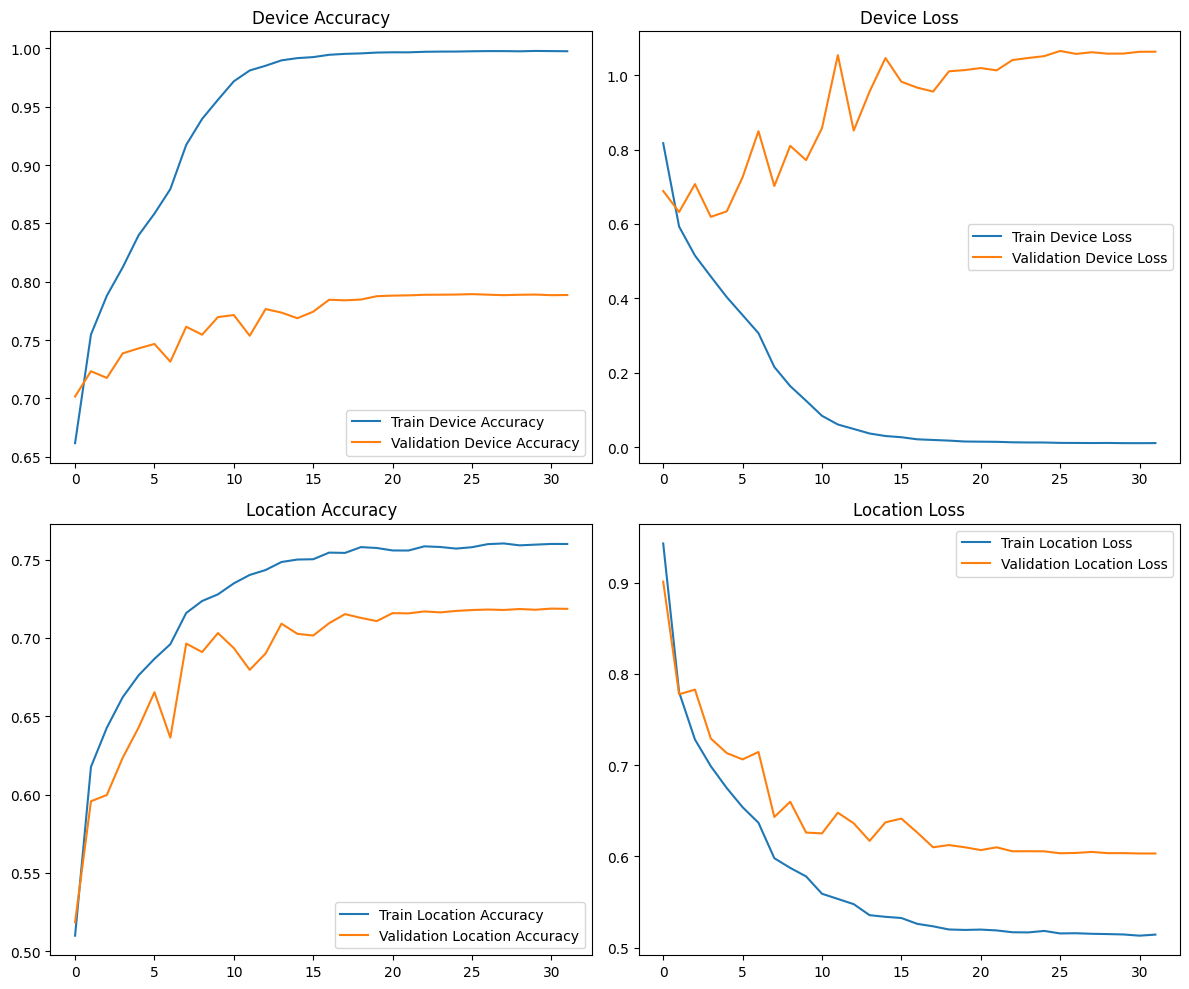

Saved training curves: results/notebook_manifest_avgmax_10000/training_curves.png


In [14]:
def save_training_curves(history, output_path: Path) -> None:
    """Save accuracy and loss curves from a Keras training history."""
    h = history.history
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(h["device_accuracy"], label="Train Device Accuracy")
    plt.plot(h["val_device_accuracy"], label="Validation Device Accuracy")
    plt.title("Device Accuracy")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(h["device_loss"], label="Train Device Loss")
    plt.plot(h["val_device_loss"], label="Validation Device Loss")
    plt.title("Device Loss")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(h["location_accuracy"], label="Train Location Accuracy")
    plt.plot(h["val_location_accuracy"], label="Validation Location Accuracy")
    plt.title("Location Accuracy")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(h["location_loss"], label="Train Location Loss")
    plt.plot(h["val_location_loss"], label="Validation Location Loss")
    plt.title("Location Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=160)


training_curves_path = RESULTS_DIR / "training_curves.png"
save_training_curves(history, training_curves_path)
plt.show(block=False)
print(f"Saved training curves: {training_curves_path}")

## Section 14: Evaluation Reporting

Window-level metrics are useful diagnostics. This section saves classification reports, confusion matrices, and per-class precision/recall/F1 tables into `RESULTS_DIR`.

In [15]:
def write_classification_report(y_true, y_pred, classes: list[str], output_path: Path) -> str:
    """Write the sklearn classification report and return it."""
    labels = list(range(len(classes)))
    report = classification_report(y_true, y_pred, labels=labels, target_names=classes, zero_division=0)
    output_path.write_text(report, encoding="utf-8")
    return report


def classification_report_table(y_true, y_pred, classes: list[str], output_path: Path) -> pd.DataFrame:
    """Save per-class precision, recall, and F1 as a CSV table."""
    labels = list(range(len(classes)))
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=classes,
        zero_division=0,
        output_dict=True,
    )
    rows = []
    for class_name in classes:
        metrics = report_dict[class_name]
        rows.append(
            {
                "class": class_name,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1_score": metrics["f1-score"],
                "support": metrics["support"],
            }
        )
    table = pd.DataFrame(rows)
    table.to_csv(output_path, index=False)
    return table


def save_confusion_matrix_plot(y_true, y_pred, classes: list[str], output_path: Path, title: str) -> None:
    """Save a confusion-matrix heatmap."""
    labels = list(range(len(classes)))
    matrix = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()

In [16]:
test_metrics = model.evaluate(
    X_test,
    {"device": y_dev_test_cat, "location": y_loc_test_cat},
    verbose=0,
    return_dict=True,
)
print("Window-level test metrics:")
for name, value in test_metrics.items():
    print(f"  {name}: {value:.4f}")

device_probs, location_probs = model.predict(X_test, verbose=0)
device_pred = np.argmax(device_probs, axis=1)
location_pred = np.argmax(location_probs, axis=1)

device_report = write_classification_report(
    y_dev_test,
    device_pred,
    CLASSES,
    RESULTS_DIR / "device_classification_report.txt",
)
location_report = write_classification_report(
    y_loc_test,
    location_pred,
    LOCATIONS,
    RESULTS_DIR / "location_classification_report.txt",
)
device_metrics_table = classification_report_table(
    y_dev_test,
    device_pred,
    CLASSES,
    RESULTS_DIR / "device_per_class_metrics.csv",
)
location_metrics_table = classification_report_table(
    y_loc_test,
    location_pred,
    LOCATIONS,
    RESULTS_DIR / "location_per_class_metrics.csv",
)

print("\nDEVICE CLASSIFICATION REPORT")
print(device_report)
print("LOCATION CLASSIFICATION REPORT")
print(location_report)

print(device_metrics_table.to_string(index=False))
print(location_metrics_table.to_string(index=False))

Window-level test metrics:
  device_accuracy: 0.8084
  device_loss: 0.9130
  location_accuracy: 0.7138
  location_loss: 0.6327
  loss: 1.2282

DEVICE CLASSIFICATION REPORT
              precision    recall  f1-score   support

   dooralarm       0.81      0.68      0.74      7323
        lora       0.94      0.87      0.91      7323
  microphone       1.00      1.00      1.00      7323
        mbus       0.79      0.76      0.78      7323
      sigfox       0.71      0.71      0.71      7323
        miwi       0.65      0.82      0.72      7323

    accuracy                           0.81     43938
   macro avg       0.82      0.81      0.81     43938
weighted avg       0.82      0.81      0.81     43938

LOCATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

 anotherroom       0.66      0.53      0.59     14646
    sameroom       0.68      0.82      0.74     14646
    upstairs       0.80      0.79      0.79     14646

    accuracy                        

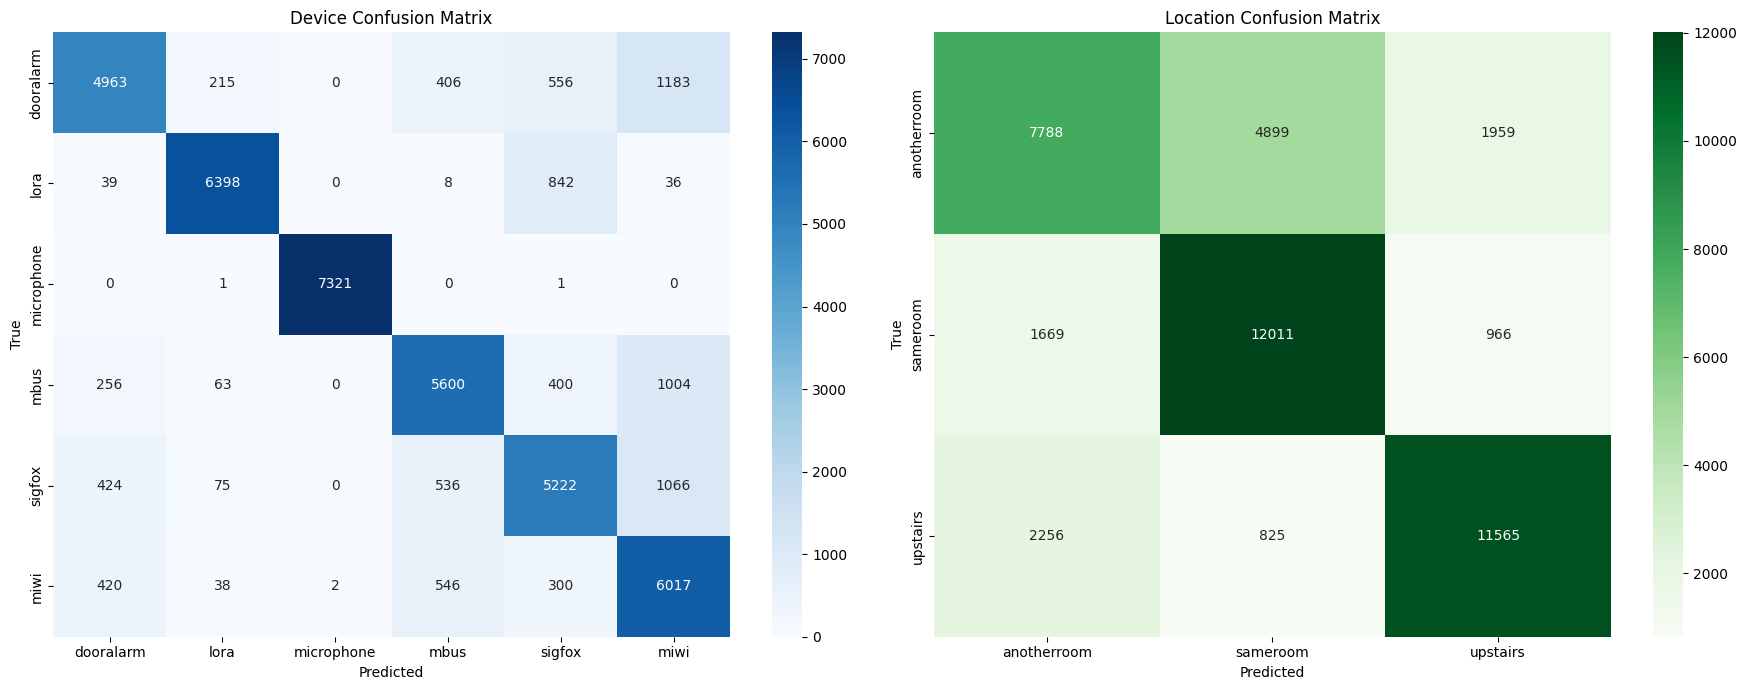

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
cm_device = confusion_matrix(y_dev_test, device_pred, labels=list(range(NUM_CLASSES)))
cm_location = confusion_matrix(y_loc_test, location_pred, labels=list(range(NUM_LOCATIONS)))

sns.heatmap(cm_device, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Device Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_location, annot=True, fmt="d", cmap="Greens", xticklabels=LOCATIONS, yticklabels=LOCATIONS, ax=axes[1])
axes[1].set_title("Location Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=160)
plt.show(block=False)

save_confusion_matrix_plot(
    y_dev_test,
    device_pred,
    CLASSES,
    RESULTS_DIR / "device_confusion_matrix.png",
    "Device Confusion Matrix",
)
save_confusion_matrix_plot(
    y_loc_test,
    location_pred,
    LOCATIONS,
    RESULTS_DIR / "location_confusion_matrix.png",
    "Location Confusion Matrix",
)

## Section 15: Run Inference on a Single Recording

This example loads one held-out recording, creates sliding-window spectrograms, runs prediction, and displays the predicted device/location with confidence scores.

In [18]:
AGGREGATION_MODES = (
    "mean",
    "log_mean",
    "median",
    "confidence_weighted",
    "top_confidence_mean",
    "vote",
)


def _normalize_scores(scores: np.ndarray) -> np.ndarray:
    """Normalize class scores into a probability vector."""
    scores = np.asarray(scores, dtype=np.float64)
    if scores.ndim != 1:
        raise ValueError("scores must be a one-dimensional array")

    total = float(np.sum(scores))
    if not np.isfinite(total) or total <= 0:
        return np.full(scores.shape, 1.0 / len(scores), dtype=np.float64)
    return scores / total


def aggregate_probabilities(
    probabilities: np.ndarray,
    mode: str = "mean",
    top_fraction: float = 0.25,
    epsilon: float = 1e-8,
) -> np.ndarray:
    """Aggregate per-window probabilities into one probability vector."""
    probabilities = np.asarray(probabilities, dtype=np.float64)
    if probabilities.ndim != 2:
        raise ValueError("probabilities must have shape (windows, classes)")
    if probabilities.shape[0] == 0 or probabilities.shape[1] == 0:
        raise ValueError("probabilities must include at least one window and class")
    if mode not in AGGREGATION_MODES:
        expected = ", ".join(AGGREGATION_MODES)
        raise ValueError(f"Unknown aggregation mode: {mode}. Expected one of: {expected}")

    if mode == "mean":
        return _normalize_scores(np.mean(probabilities, axis=0))
    if mode == "log_mean":
        scores = np.exp(np.mean(np.log(np.clip(probabilities, epsilon, 1.0)), axis=0))
        return _normalize_scores(scores)
    if mode == "median":
        return _normalize_scores(np.median(probabilities, axis=0))
    if mode == "confidence_weighted":
        weights = np.max(probabilities, axis=1)
        if float(np.sum(weights)) <= 0:
            return _normalize_scores(np.mean(probabilities, axis=0))
        return _normalize_scores(np.average(probabilities, axis=0, weights=weights))
    if mode == "top_confidence_mean":
        if not 0 < top_fraction <= 1:
            raise ValueError("top_fraction must be in the range (0, 1]")
        confidences = np.max(probabilities, axis=1)
        keep = max(1, int(math.ceil(len(confidences) * top_fraction)))
        indices = np.argpartition(confidences, -keep)[-keep:]
        return _normalize_scores(np.mean(probabilities[indices], axis=0))

    predicted_classes = np.argmax(probabilities, axis=1)
    votes = np.bincount(predicted_classes, minlength=probabilities.shape[1])
    return _normalize_scores(votes)


def load_classes(metadata_path: Path) -> list[str]:
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        return metadata.get("classes", CLASSES)
    return CLASSES


def load_locations(metadata_path: Path) -> list[str]:
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        return metadata.get("locations", LOCATIONS)
    return LOCATIONS


def predict_signal(
    model: tf.keras.Model,
    signal: np.ndarray,
    classes: list[str],
    locations: list[str] | None = None,
    window_size: int = WINDOW_SIZE,
    step: int = INFERENCE_STEP,
    aggregation: str = "mean",
    top_fraction: float = 0.25,
) -> dict[str, object]:
    locations = locations or LOCATIONS
    windows = sliding_windows(signal, window_size=window_size, step=step)
    if len(windows) == 0:
        raise ValueError(f"Input signal has {len(signal)} samples, fewer than window_size={window_size}")

    specs = windows_to_model_input(windows)
    try:
        device_probs, location_probs = model.predict(specs, verbose=0)
    except Exception as exc:
        raise RuntimeError(f"Prediction failed. Confirm the model input shape matches spectrogram shape {specs.shape}. Original error: {exc}") from exc

    avg_device_probs = aggregate_probabilities(device_probs, mode=aggregation, top_fraction=top_fraction)
    avg_location_probs = aggregate_probabilities(location_probs, mode=aggregation, top_fraction=top_fraction)

    final_device_idx = int(np.argmax(avg_device_probs))
    final_location_idx = int(np.argmax(avg_location_probs))

    return {
        "prediction": classes[final_device_idx],
        "location": locations[final_location_idx],
        "device_confidence": float(avg_device_probs[final_device_idx]),
        "location_confidence": float(avg_location_probs[final_location_idx]),
        "windows": int(len(windows)),
        "aggregation": aggregation,
        "top_fraction": float(top_fraction),
        "device_probabilities": {
            class_name: float(probability)
            for class_name, probability in zip(classes, avg_device_probs)
        },
        "location_probabilities": {
            loc_name: float(probability)
            for loc_name, probability in zip(locations, avg_location_probs)
        },
    }

In [19]:
print(f"Supported aggregation modes: {AGGREGATION_MODES}")

test_recs = load_manifest(MANIFEST_PATH, classes=CLASSES, split="test", dataset_root=DATASET_ROOT)
example = test_recs[0]
signal = load_signal_file(example.path)
example_windows = sliding_windows(signal, window_size=WINDOW_SIZE, step=INFERENCE_STEP)
example_specs = windows_to_model_input(example_windows[:1])
result = predict_signal(
    model,
    signal,
    CLASSES,
    locations=LOCATIONS,
    window_size=WINDOW_SIZE,
    step=INFERENCE_STEP,
    aggregation=AGGREGATION,
    top_fraction=TOP_FRACTION,
)

single_prediction = pd.DataFrame(
    [
        {
            "file": str(example.path),
            "true_device": example.class_name,
            "predicted_device": result["prediction"],
            "device_confidence": result["device_confidence"],
            "true_location": example.scenario,
            "predicted_location": result["location"],
            "location_confidence": result["location_confidence"],
            "windows": result["windows"],
            "example_spectrogram_shape": tuple(example_specs.shape),
        }
    ]
)
print(single_prediction.to_string(index=False))
print(json.dumps(result, indent=2))

Supported aggregation modes: ('mean', 'log_mean', 'median', 'confidence_weighted', 'top_confidence_mean', 'vote')
                                               file true_device predicted_device  device_confidence true_location predicted_location  location_confidence  windows example_spectrogram_shape
data/recordings/dooralarm/anotherroom_capture21.npy   dooralarm        dooralarm           0.726913   anotherroom        anotherroom             0.794073     9762           (1, 257, 61, 1)
{
  "prediction": "dooralarm",
  "location": "anotherroom",
  "device_confidence": 0.7269134583969932,
  "location_confidence": 0.7940729497425341,
  "windows": 9762,
  "aggregation": "mean",
  "top_fraction": 0.25,
  "device_probabilities": {
    "dooralarm": 0.7269134583969932,
    "lora": 0.0028721074002657325,
    "microphone": 2.318606447983749e-05,
    "mbus": 0.07805803487395448,
    "sigfox": 0.04822921773635719,
    "miwi": 0.1439039955279496
  },
  "location_probabilities": {
    "anotherroom"

## Section 16: Results Visualization

This section displays representative spectrograms and saves visual artifacts for review.

/var/folders/q8/9y_plmt93cv2qz_hl0vw90nr0000gn/T/ipykernel_15717/151479199.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


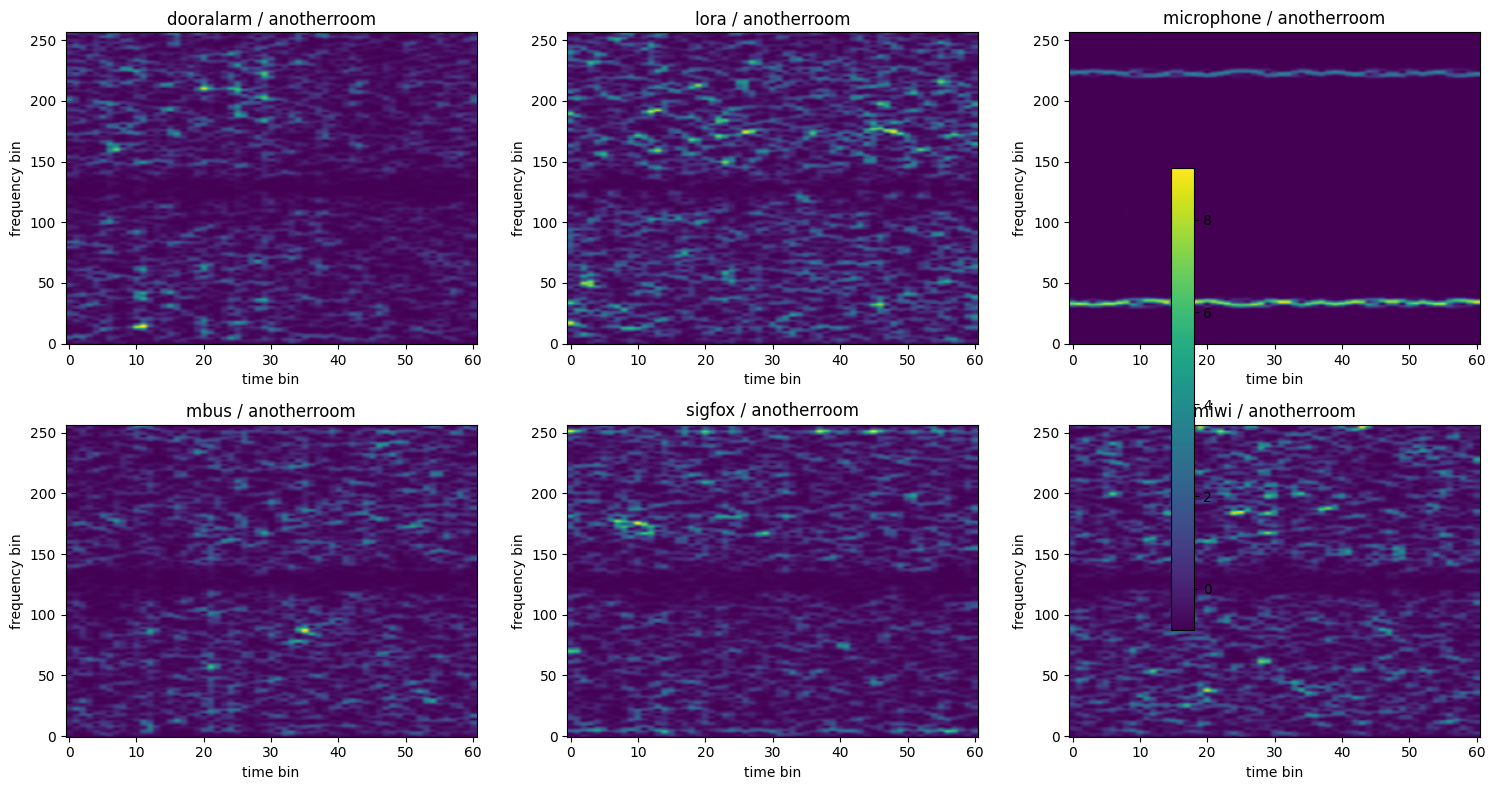

In [20]:
train_recs = load_manifest(MANIFEST_PATH, classes=CLASSES, split="train", dataset_root=DATASET_ROOT)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, class_name in zip(axes.ravel(), CLASSES):
    rec = next(r for r in train_recs if r.class_name == class_name)
    raw = load_signal_file(rec.path)
    window = segment_signal(raw, window_size=WINDOW_SIZE)[0:1]
    spec = windows_to_model_input(window)[0, :, :, 0]
    im = ax.imshow(spec, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"{class_name} / {rec.scenario}")
    ax.set_xlabel("time bin")
    ax.set_ylabel("frequency bin")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_spectrograms.png", dpi=160)
plt.show(block=False)

## Section 17: File-Level Test Evaluation

Whole-recording evaluation uses overlapping windows and probability aggregation. Each held-out recording contributes one prediction, which better matches deployment behavior than treating correlated windows as independent examples.

In [21]:
def write_file_predictions(rows: list[dict[str, object]], output_path: Path) -> None:
    """Write one row per test signal file."""
    with output_path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(
            handle,
            fieldnames=[
                "file",
                "true_label",
                "predicted_label",
                "confidence",
                "true_location",
                "predicted_location",
                "location_confidence",
                "scenario",
                "capture_id",
                "split",
                "device_correct",
                "location_correct",
                "windows",
            ],
        )
        writer.writeheader()
        for row in rows:
            writer.writerow(row)


def wilson_confidence_interval(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    """Return a Wilson score confidence interval for a binomial accuracy."""
    if total <= 0:
        return 0.0, 0.0

    proportion = successes / total
    denominator = 1 + (z**2 / total)
    center = (proportion + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((proportion * (1 - proportion) / total) + (z**2 / (4 * total**2))) / denominator
    low = 0.0 if successes == 0 else max(0.0, float(center - margin))
    high = 1.0 if successes == total else min(1.0, float(center + margin))
    return low, high


def summarize_scenarios(rows: list[dict[str, object]]) -> dict[str, dict[str, object]]:
    """Summarize independent file-level outcomes for each scenario."""
    grouped_dev: dict[str, list[int]] = {}
    grouped_loc: dict[str, list[int]] = {}
    for row in rows:
        scenario = str(row.get("scenario") or "unspecified")
        correct_dev = row.get("device_correct")
        if correct_dev is not None:
            grouped_dev.setdefault(scenario, []).append(int(correct_dev))
        correct_loc = row.get("location_correct")
        if correct_loc is not None:
            grouped_loc.setdefault(scenario, []).append(int(correct_loc))

    summary: dict[str, dict[str, object]] = {}
    for scenario in sorted(set(grouped_dev.keys()).union(grouped_loc.keys())):
        dev_corr = grouped_dev.get(scenario, [])
        loc_corr = grouped_loc.get(scenario, [])
        entry: dict[str, object] = {"files": max(len(dev_corr), len(loc_corr))}

        if dev_corr:
            dev_correct_files = int(sum(dev_corr))
            dev_low, dev_high = wilson_confidence_interval(dev_correct_files, len(dev_corr))
            entry["device_correct_files"] = dev_correct_files
            entry["device_accuracy"] = float(dev_correct_files / len(dev_corr))
            entry["device_accuracy_ci_95_wilson"] = {"low": dev_low, "high": dev_high}

        if loc_corr:
            loc_correct_files = int(sum(loc_corr))
            loc_low, loc_high = wilson_confidence_interval(loc_correct_files, len(loc_corr))
            entry["location_correct_files"] = loc_correct_files
            entry["location_accuracy"] = float(loc_correct_files / len(loc_corr))
            entry["location_accuracy_ci_95_wilson"] = {"low": loc_low, "high": loc_high}

        summary[scenario] = entry
    return summary


def run_test(
    model_path: Path,
    metadata_path: Path,
    data_dir: Path | None,
    output_dir: Path,
    window_size: int = WINDOW_SIZE,
    step: int = INFERENCE_STEP,
    file_template: str | None = None,
    allow_missing: bool = True,
    manifest_path: Path | None = None,
    manifest_split: str = "test",
    aggregation: str = "mean",
    top_fraction: float = 0.25,
    dataset_root: Path = DATASET_ROOT,
) -> dict[str, object]:
    """Run file-level sliding-window ensemble tests and save reports."""
    classes = load_classes(metadata_path)
    locations = load_locations(metadata_path)
    if manifest_path:
        recordings_for_test = load_manifest(manifest_path, classes=classes, split=manifest_split, dataset_root=dataset_root)
        if not allow_missing:
            available = {recording.class_name for recording in recordings_for_test}
            missing = [class_name for class_name in classes if class_name not in available]
            if missing:
                raise ValueError(f"Manifest split={manifest_split} has no recordings for classes: {', '.join(missing)}")
    elif data_dir:
        recordings_for_test = legacy_recordings(data_dir, classes=classes, file_template=file_template, allow_missing=allow_missing)
    else:
        raise ValueError("Provide data_dir or manifest_path")

    output_dir.mkdir(parents=True, exist_ok=True)
    try:
        loaded_model = tf.keras.models.load_model(str(model_path))
    except Exception as exc:
        raise RuntimeError(f"Could not load model from {model_path}. Run training first or update model_path. Original error: {exc}") from exc

    rows: list[dict[str, object]] = []
    probabilities_by_file: dict[str, dict[str, object]] = {}
    y_dev_true: list[int] = []
    y_dev_pred: list[int] = []
    y_loc_true: list[int] = []
    y_loc_pred: list[int] = []

    for recording in recordings_for_test:
        signal = load_signal_file(recording.path)
        result = predict_signal(
            loaded_model,
            signal,
            classes,
            locations=locations,
            window_size=window_size,
            step=step,
            aggregation=aggregation,
            top_fraction=top_fraction,
        )

        true_dev_idx = classes.index(recording.class_name)
        pred_dev_idx = classes.index(str(result["prediction"]))
        dev_correct = int(true_dev_idx == pred_dev_idx)
        true_loc_idx = locations.index(recording.scenario) if recording.scenario in locations else -1
        pred_loc_idx = locations.index(str(result["location"]))
        loc_correct = int(true_loc_idx == pred_loc_idx)

        y_dev_true.append(true_dev_idx)
        y_dev_pred.append(pred_dev_idx)
        if true_loc_idx >= 0:
            y_loc_true.append(true_loc_idx)
            y_loc_pred.append(pred_loc_idx)

        probabilities_by_file[str(recording.path)] = {
            "device_probabilities": result["device_probabilities"],
            "location_probabilities": result["location_probabilities"],
        }
        rows.append(
            {
                "file": str(recording.path),
                "true_label": recording.class_name,
                "predicted_label": result["prediction"],
                "confidence": f"{float(result['device_confidence']):.8f}",
                "true_location": recording.scenario,
                "predicted_location": result["location"],
                "location_confidence": f"{float(result['location_confidence']):.8f}",
                "scenario": recording.scenario,
                "capture_id": recording.capture_id,
                "split": recording.split or "",
                "device_correct": dev_correct,
                "location_correct": loc_correct,
                "windows": int(result["windows"]),
            }
        )

    y_dev_true_array = np.asarray(y_dev_true, dtype=np.int64)
    y_dev_pred_array = np.asarray(y_dev_pred, dtype=np.int64)
    correct_dev_files = int(np.sum(y_dev_true_array == y_dev_pred_array))
    dev_accuracy = float(correct_dev_files / len(y_dev_true_array)) if len(y_dev_true_array) else 0.0
    dev_accuracy_ci_low, dev_accuracy_ci_high = wilson_confidence_interval(correct_dev_files, len(y_dev_true_array))

    y_loc_true_array = np.asarray(y_loc_true, dtype=np.int64)
    y_loc_pred_array = np.asarray(y_loc_pred, dtype=np.int64)
    correct_loc_files = int(np.sum(y_loc_true_array == y_loc_pred_array))
    loc_accuracy = float(correct_loc_files / len(y_loc_true_array)) if len(y_loc_true_array) else 0.0
    loc_accuracy_ci_low, loc_accuracy_ci_high = wilson_confidence_interval(correct_loc_files, len(y_loc_true_array))

    file_device_report = write_classification_report(y_dev_true_array, y_dev_pred_array, classes, output_dir / "file_device_classification_report.txt")
    save_confusion_matrix_plot(y_dev_true_array, y_dev_pred_array, classes, output_dir / "file_device_confusion_matrix.png", "File-Level Device Confusion Matrix")
    file_location_report = write_classification_report(y_loc_true_array, y_loc_pred_array, locations, output_dir / "file_location_classification_report.txt")
    save_confusion_matrix_plot(y_loc_true_array, y_loc_pred_array, locations, output_dir / "file_location_confusion_matrix.png", "File-Level Location Confusion Matrix")
    write_file_predictions(rows, output_dir / "predictions.csv")
    (output_dir / "probabilities.json").write_text(json.dumps(probabilities_by_file, indent=2), encoding="utf-8")

    metrics = {
        "evaluation_role": "external-file-level-ensemble",
        "evaluation_unit": "source_file",
        "data_dir": str(data_dir) if data_dir else None,
        "manifest": str(manifest_path) if manifest_path else None,
        "manifest_split": manifest_split if manifest_path else None,
        "model": str(model_path),
        "files": len(rows),
        "correct_device_files": correct_dev_files,
        "device_accuracy": dev_accuracy,
        "device_accuracy_ci_95_wilson": {"low": dev_accuracy_ci_low, "high": dev_accuracy_ci_high},
        "correct_location_files": correct_loc_files,
        "location_accuracy": loc_accuracy,
        "location_accuracy_ci_95_wilson": {"low": loc_accuracy_ci_low, "high": loc_accuracy_ci_high},
        "interpretation": "Each file contributes one prediction; window count is not the number of independent test examples.",
        "scenario_metrics": summarize_scenarios(rows),
        "window_size": int(window_size),
        "step": int(step),
        "aggregation": aggregation,
        "top_fraction": float(top_fraction),
    }
    (output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    print(f"Tested {len(rows)} files")
    print(f"File-level Device Accuracy: {dev_accuracy:.4f}")
    print(f"File-level Location Accuracy: {loc_accuracy:.4f}")
    print("\n--- File-Level Device Classification Report ---")
    print(file_device_report)
    print("\n--- File-Level Location Classification Report ---")
    print(file_location_report)
    print(f"Saved reports to: {output_dir}")

    return metrics

In [22]:
window_metadata = {
    "classes": CLASSES,
    "locations": LOCATIONS,
    "split_strategy": "recording_manifest",
    "dataset": {
        "dataset_root": str(DATASET_ROOT),
        "manifest": str(MANIFEST_PATH),
        "recordings_total": len(recordings),
        "recordings_by_split": dict(sorted(split_counts.items())),
        "recordings_by_scenario": dict(sorted(scenario_counts.items())),
        "recordings_by_class": dict((class_name, class_counts[class_name]) for class_name in CLASSES),
    },
    "test_evaluation_role": "held-out-recordings-from-manifest",
    "test_evaluation_unit": "non_overlapping_window",
    "test_samples": int(len(y_dev_test)),
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "input_shape": list(X_train.shape[1:]),
    "balanced": True,
    "max_windows_per_class": MAX_WINDOWS_PER_CLASS,
    "pooling": POOLING,
}

(MODEL_DIR / "metadata.json").write_text(json.dumps(window_metadata, indent=2), encoding="utf-8")
print(json.dumps(window_metadata, indent=2))

{
  "classes": [
    "dooralarm",
    "lora",
    "microphone",
    "mbus",
    "sigfox",
    "miwi"
  ],
  "locations": [
    "anotherroom",
    "sameroom",
    "upstairs"
  ],
  "split_strategy": "recording_manifest",
  "dataset": {
    "dataset_root": "data",
    "manifest": "data/recordings_manifest.csv",
    "recordings_total": 378,
    "recordings_by_split": {
      "test": 18,
      "train": 288,
      "validation": 72
    },
    "recordings_by_scenario": {
      "anotherroom": 126,
      "sameroom": 126,
      "upstairs": 126
    },
    "recordings_by_class": {
      "dooralarm": 63,
      "lora": 63,
      "microphone": 63,
      "mbus": 63,
      "sigfox": 63,
      "miwi": 63
    }
  },
  "test_evaluation_role": "held-out-recordings-from-manifest",
  "test_evaluation_unit": "non_overlapping_window",
  "test_samples": 43938,
  "test_metrics": {
    "device_accuracy": 0.8084346055984497,
    "device_loss": 0.9130380749702454,
    "location_accuracy": 0.7138240337371826,
    "l

In [23]:
file_metrics = run_test(
    model_path=best_model_path,
    metadata_path=MODEL_DIR / "metadata.json",
    data_dir=None,
    output_dir=RESULTS_DIR,
    window_size=WINDOW_SIZE,
    step=INFERENCE_STEP,
    manifest_path=MANIFEST_PATH,
    manifest_split="test",
    aggregation=AGGREGATION,
    top_fraction=TOP_FRACTION,
    dataset_root=DATASET_ROOT,
)

print(json.dumps(file_metrics, indent=2))

Tested 18 files
File-level Device Accuracy: 1.0000
File-level Location Accuracy: 0.7778

--- File-Level Device Classification Report ---
              precision    recall  f1-score   support

   dooralarm       1.00      1.00      1.00         3
        lora       1.00      1.00      1.00         3
  microphone       1.00      1.00      1.00         3
        mbus       1.00      1.00      1.00         3
      sigfox       1.00      1.00      1.00         3
        miwi       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


--- File-Level Location Classification Report ---
              precision    recall  f1-score   support

 anotherroom       0.75      0.50      0.60         6
    sameroom       0.67      1.00      0.80         6
    upstairs       1.00      0.83      0.91         6

    accuracy                           0.78        

## Section 18: Training Metadata

This metadata file captures the run timestamp, dataset size, hyperparameters, and final metrics so the experiment can be reviewed or compared later.

In [24]:
def last_history_value(history, key: str) -> float | None:
    values = history.history.get(key)
    if not values:
        return None
    return float(values[-1])

training_metadata = {
    "training_timestamp": datetime.now(timezone.utc).isoformat(),
    "dataset_size": {
        "recordings": len(recordings),
        "train_windows": int(len(y_dev_train)),
        "validation_windows": int(len(y_dev_val)),
        "test_windows": int(len(y_dev_test)),
    },
    "number_of_classes": NUM_CLASSES,
    "number_of_locations": NUM_LOCATIONS,
    "hyperparameters": {
        "window_size": WINDOW_SIZE,
        "fft_size": FFT_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_configured": EPOCHS,
        "epochs_completed": len(history.history.get("loss", [])),
        "learning_rate": LEARNING_RATE,
        "pooling": POOLING,
        "max_windows_per_class": MAX_WINDOWS_PER_CLASS,
        "aggregation": AGGREGATION,
        "top_fraction": TOP_FRACTION,
        "random_seed": RANDOM_SEED,
    },
    "final_accuracy": last_history_value(history, "device_accuracy"),
    "final_validation_accuracy": last_history_value(history, "val_device_accuracy"),
    "test_accuracy": float(test_metrics.get("device_accuracy", 0.0)),
    "file_level_device_accuracy": float(file_metrics.get("device_accuracy", 0.0)),
    "file_level_location_accuracy": float(file_metrics.get("location_accuracy", 0.0)),
    "artifacts": {
        "best_model": str(best_model_path),
        "final_model": str(final_model_path),
        "results_dir": str(RESULTS_DIR),
    },
}

training_metadata_path = RESULTS_DIR / "training_metadata.json"
training_metadata_path.write_text(json.dumps(training_metadata, indent=2), encoding="utf-8")
print(f"Saved training metadata: {training_metadata_path}")
print(json.dumps(training_metadata, indent=2))

Saved training metadata: results/notebook_manifest_avgmax_10000/training_metadata.json
{
  "training_timestamp": "2026-06-14T14:29:54.043535+00:00",
  "dataset_size": {
    "recordings": 378,
    "train_windows": 60000,
    "validation_windows": 60000,
    "test_windows": 43938
  },
  "number_of_classes": 6,
  "number_of_locations": 3,
  "hyperparameters": {
    "window_size": 4096,
    "fft_size": 512,
    "batch_size": 32,
    "epochs_configured": 50,
    "epochs_completed": 32,
    "learning_rate": 0.0003,
    "pooling": "avgmax",
    "max_windows_per_class": 10000,
    "aggregation": "mean",
    "top_fraction": 0.25,
    "random_seed": 42
  },
  "final_accuracy": 0.9976000189781189,
  "final_validation_accuracy": 0.7886666655540466,
  "test_accuracy": 0.8084346055984497,
  "file_level_device_accuracy": 1.0,
  "file_level_location_accuracy": 0.7777777777777778,
  "artifacts": {
    "best_model": "models/notebook_manifest_avgmax_10000/best_iot_classifier.h5",
    "final_model": "mode